# Lab 3 — Character-level GPT for Poetry Generation



1. Mount Google Drive
2. Install dependencies
3. Write source files
4. Train the model
5. Generate poetry


## Mount Google Drive & set working directory

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

# !! Change this to the folder where you uploaded the corpus !!
LAB_DIR = '/content/drive/MyDrive/lab3'

os.makedirs(LAB_DIR, exist_ok=True)
os.chdir(LAB_DIR)
print('Working directory:', os.getcwd())
print('Files:', os.listdir('.'))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/lab3
Files: ['corpus_poetique_fr_main.txt', '__pycache__', 'runs', 'dataset.py', 'model.py', 'lab3_colab_old.ipynb', 'lab3_colab.ipynb']


## Check GPU

In [2]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


## Write dataset.py

In [3]:
%%writefile dataset.py
"""
Character-level dataset for poetry corpus.
"""

import torch
from torch.utils.data import Dataset


class CharDataset(Dataset):
    """
    Sliding-window character-level dataset.
    Each sample is a (context, target) pair of length `block_size`,
    where target is context shifted by one character.
    """

    def __init__(self, text: str, block_size: int):
        self.block_size = block_size

        chars = sorted(set(text))
        self.vocab_size = len(chars)
        self.char2idx = {c: i for i, c in enumerate(chars)}
        self.idx2char = {i: c for i, c in enumerate(chars)}

        self.data = torch.tensor([self.char2idx[c] for c in text], dtype=torch.long)

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        chunk = self.data[idx: idx + self.block_size + 1]
        return chunk[:-1], chunk[1:]

    def encode(self, text: str) -> torch.Tensor:
        return torch.tensor(
            [self.char2idx.get(c, 0) for c in text], dtype=torch.long
        )

    def decode(self, indices) -> str:
        return "".join(self.idx2char[i] for i in indices)


def load_corpus(path: str) -> str:
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def split_corpus(text: str, val_ratio: float = 0.05):
    split = int(len(text) * (1 - val_ratio))
    return text[:split], text[split:]

print('dataset.py written.')

Overwriting dataset.py


## Write model.py

In [4]:
%%writefile model.py
"""
Character-level GPT model (decoder-only Transformer).

Two attention backends:
  'flash'  : F.scaled_dot_product_attention (FlashAttention when available)
  'manual' : explicit triangular causal mask

Positional encoding: learned embeddings.
"""

import math
import torch
import torch.nn as nn
import torch.nn.functional as F


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout, block_size, backend='flash'):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.backend = backend
        self.dropout = dropout

        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.attn_drop = nn.Dropout(dropout)

        if backend == 'manual':
            mask = torch.tril(torch.ones(block_size, block_size))
            self.register_buffer('mask', mask)

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=-1)

        def reshape(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q, k, v = reshape(q), reshape(k), reshape(v)

        if self.backend == 'flash':
            attn_out = F.scaled_dot_product_attention(
                q, k, v,
                attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0,
                is_causal=True,
            )
        else:
            scale = 1.0 / math.sqrt(self.head_dim)
            scores = (q @ k.transpose(-2, -1)) * scale
            scores = scores.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
            attn_weights = F.softmax(scores, dim=-1)
            attn_weights = self.attn_drop(attn_weights)
            attn_out = attn_weights @ v

        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(attn_out)


class FeedForward(nn.Module):
    def __init__(self, d_model, expansion, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, expansion * d_model),
            nn.GELU(),
            nn.Linear(expansion * d_model, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout, block_size, mlp_expansion, backend):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout, block_size, backend)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, mlp_expansion, dropout)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = x + self.drop(self.attn(self.ln1(x)))
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x


class CharGPT(nn.Module):
    def __init__(self, vocab_size, d_model=256, n_heads=8, n_layers=6,
                 block_size=256, dropout=0.1, mlp_expansion=4, backend='flash'):
        super().__init__()
        self.block_size = block_size

        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb   = nn.Embedding(block_size, d_model)
        self.drop      = nn.Dropout(dropout)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, dropout, block_size, mlp_expansion, backend)
            for _ in range(n_layers)
        ])

        self.ln_f    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.token_emb.weight  # weight tying

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.token_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print('model.py written.')

Overwriting model.py


## Load corpus & build dataset

In [5]:
import torch
from torch.utils.data import DataLoader
from dataset import CharDataset, load_corpus, split_corpus
from model import CharGPT

CORPUS = 'corpus_poetique_fr_main.txt'   # change to _quick for fast test
BLOCK_SIZE = 256

text = load_corpus(CORPUS)
train_text, val_text = split_corpus(text, val_ratio=0.05)

train_ds = CharDataset(train_text, BLOCK_SIZE)
val_ds   = CharDataset(val_text,   BLOCK_SIZE)

# Share vocab from train
val_ds.char2idx  = train_ds.char2idx
val_ds.idx2char  = train_ds.idx2char
val_ds.vocab_size = train_ds.vocab_size
val_ds.data = torch.tensor(
    [train_ds.char2idx.get(c, 0) for c in val_text], dtype=torch.long
)

print(f'Corpus: {CORPUS}')
print(f'Train chars: {len(train_text):,}  |  Val chars: {len(val_text):,}')
print(f'Vocab size:  {train_ds.vocab_size}')
print(f'Train samples: {len(train_ds):,}')

dataset.py written.
model.py written.
Corpus: corpus_poetique_fr_main.txt
Train chars: 7,728,699  |  Val chars: 406,774
Vocab size:  127
Train samples: 7,728,443


## Training configuration

In [6]:
# ── Hyperparameters ────────────────────────────────────────────────
CONFIG = dict(
    d_model      = 256,
    n_heads      = 8,
    n_layers     = 6,
    block_size   = BLOCK_SIZE,
    dropout      = 0.1,
    mlp_expansion= 4,
    backend      = 'flash',    # 'flash' or 'manual'

    batch_size   = 64,
    lr           = 3e-4,
    steps        = 30000,
    warmup_steps = 500,

    log_every    = 100,
    eval_every   = 500,
    sample_every = 2000,
    ckpt_every   = 5000,
    out_dir      = 'runs/main',
)
# ──────────────────────────────────────────────────────────────────

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

os.makedirs(CONFIG['out_dir'], exist_ok=True)

Device: cuda


## Build model & optimizer

In [7]:
model = CharGPT(
    vocab_size    = train_ds.vocab_size,
    d_model       = CONFIG['d_model'],
    n_heads       = CONFIG['n_heads'],
    n_layers      = CONFIG['n_layers'],
    block_size    = CONFIG['block_size'],
    dropout       = CONFIG['dropout'],
    mlp_expansion = CONFIG['mlp_expansion'],
    backend       = CONFIG['backend'],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=0.1,
    betas=(0.9, 0.95),
)

print(f'Parameters: {model.count_parameters():,}')
print(f'Backend:    {CONFIG["backend"]}')

Parameters: 4,830,976
Backend:    flash


## Helper functions

In [8]:
# ── Helper functions (safe to re-run after session restart) ──────
import math, time, json

def get_lr(step, warmup, max_lr, min_lr, total):
    if step < warmup:
        return max_lr * step / max(warmup, 1)
    if step >= total:
        return min_lr
    progress = (step - warmup) / (total - warmup)
    return min_lr + 0.5 * (max_lr - min_lr) * (1 + math.cos(math.pi * progress))

def bits_per_char(loss):
    return loss / math.log(2)

@torch.no_grad()
def evaluate(model, dataset, batch_size, device, n_batches=20):
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    total, count = 0.0, 0
    for x, y in loader:
        if count >= n_batches: break
        _, loss = model(x.to(device), y.to(device))
        total += loss.item(); count += 1
    model.train()
    return total / max(count, 1)

@torch.no_grad()
def generate_sample(model, dataset, device, prompt='\n', max_tokens=300, temperature=0.8):
    model.eval()
    idx = dataset.encode(prompt).unsqueeze(0).to(device)
    for _ in range(max_tokens):
        idx_cond = idx[:, -model.block_size:]
        logits, _ = model(idx_cond)
        probs = torch.softmax(logits[:, -1, :] / temperature, dim=-1)
        next_char = torch.multinomial(probs, 1)
        idx = torch.cat([idx, next_char], dim=1)
    model.train()
    return dataset.decode(idx[0].tolist())

print("Helper functions defined.")


Helper functions defined.


## Training loop

In [9]:
# TRAINING LOOP — DO NOT RE-RUN if checkpoint already exists!
import os
if os.path.exists(os.path.join(CONFIG['out_dir'], 'ckpt_final.pt')):
    print('Checkpoint found — skipping training.')
else:
    train_loader = DataLoader(
        train_ds, batch_size=CONFIG['batch_size'],
        shuffle=True, drop_last=True, pin_memory=True
    )
    log_path    = os.path.join(CONFIG['out_dir'], 'train_log.jsonl')
    sample_path = os.path.join(CONFIG['out_dir'], 'samples.txt')
    min_lr      = CONFIG['lr'] / 10

    model.train()
    step, data_iter = 0, iter(train_loader)
    t0 = time.time()
    train_losses, val_losses, steps_logged = [], [], []

    print('Training for', CONFIG['steps'], 'steps on', str(device))
    print()

    while step < CONFIG['steps']:
        lr = get_lr(step, CONFIG['warmup_steps'], CONFIG['lr'], min_lr, CONFIG['steps'])
        for pg in optimizer.param_groups:
            pg['lr'] = lr
        try:
            x, y = next(data_iter)
        except StopIteration:
            data_iter = iter(train_loader)
            x, y = next(data_iter)
        x, y = x.to(device), y.to(device)
        _, loss = model(x, y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        step += 1

        if step % CONFIG['log_every'] == 0:
            bpc = bits_per_char(loss.item())
            elapsed = time.time() - t0
            rec = {'step': step, 'train_loss': round(loss.item(), 4),
                   'bpc': round(bpc, 4), 'lr': round(lr, 6), 'elapsed_s': round(elapsed, 1)}
            with open(log_path, 'a') as fout:
                fout.write(json.dumps(rec) + chr(10))
            train_losses.append(loss.item())
            steps_logged.append(step)
            print(f'step {step:>6} | loss {loss.item():.4f} | bpc {bpc:.4f} | lr {lr:.2e} | {elapsed:.0f}s')

        if step % CONFIG['eval_every'] == 0:
            val_loss = evaluate(model, val_ds, CONFIG['batch_size'], device)
            rec = {'step': step, 'val_loss': round(val_loss, 4),
                   'val_bpc': round(bits_per_char(val_loss), 4)}
            with open(log_path, 'a') as fout:
                fout.write(json.dumps(rec) + chr(10))
            val_losses.append((step, val_loss))
            print(f'  [val]  loss {val_loss:.4f} | bpc {bits_per_char(val_loss):.4f}')

        if step % CONFIG['sample_every'] == 0:
            sample = generate_sample(model, train_ds, device)
            print('--- Sample @ step', step, '---')
            print(sample[:400])
            print('---')
            with open(sample_path, 'a') as fout:
                fout.write('=== step ' + str(step) + ' ===' + chr(10))
                fout.write(sample + chr(10))

        if step % CONFIG['ckpt_every'] == 0:
            ckpt_path = os.path.join(CONFIG['out_dir'], f'ckpt_{step:06d}.pt')
            torch.save({'step': step, 'model_state': model.state_dict(),
                        'optimizer_state': optimizer.state_dict(), 'config': CONFIG,
                        'vocab_size': train_ds.vocab_size,
                        'char2idx': train_ds.char2idx, 'idx2char': train_ds.idx2char}, ckpt_path)
            print('  Checkpoint saved:', ckpt_path)

    final_path = os.path.join(CONFIG['out_dir'], 'ckpt_final.pt')
    torch.save({'step': step, 'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(), 'config': CONFIG,
                'vocab_size': train_ds.vocab_size,
                'char2idx': train_ds.char2idx, 'idx2char': train_ds.idx2char}, final_path)
    print('Done! Final checkpoint:', final_path)


Checkpoint found — skipping training.


## Plot learning curves

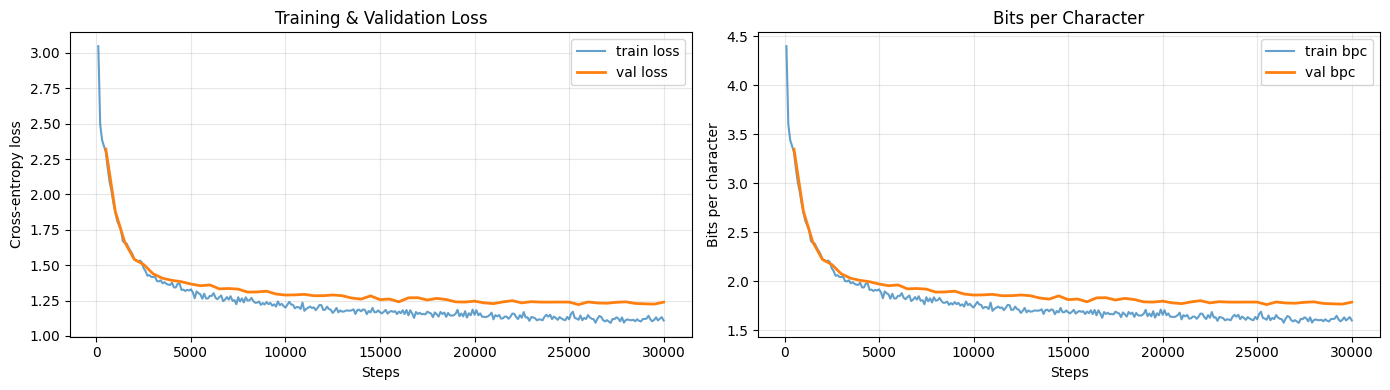

Plot saved.


In [ ]:
import matplotlib.pyplot as plt

# Read log
train_steps, train_bpcs = [], []
val_steps,   val_bpcs   = [], []

with open(log_path) as f:
    for line in f:
        rec = json.loads(line)
        if 'train_loss' in rec:
            train_steps.append(rec['step'])
            train_bpcs.append(rec['bpc'])
        if 'val_loss' in rec:
            val_steps.append(rec['step'])
            val_bpcs.append(rec['val_bpc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
ax = axes[0]
ax.plot(train_steps, [l * math.log(2) for l in train_bpcs], label='train loss', alpha=0.7)
if val_steps:
    ax.plot(val_steps, [v * math.log(2) for v in val_bpcs], label='val loss', linewidth=2)
ax.set_xlabel('Steps'); ax.set_ylabel('Cross-entropy loss'); ax.set_title('Training & Validation Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# BPC
ax = axes[1]
ax.plot(train_steps, train_bpcs, label='train bpc', alpha=0.7)
if val_steps:
    ax.plot(val_steps, val_bpcs, label='val bpc', linewidth=2)
ax.set_xlabel('Steps'); ax.set_ylabel('Bits per character'); ax.set_title('Bits per Character')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['out_dir'], 'learning_curves.png'), dpi=150)
plt.show()
print('Plot saved.')

## Generate poetry

In [12]:
ckpt = torch.load('runs/main/ckpt_final.pt', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print('Model loaded! Step:', ckpt['step'])


Model loaded! Step: 30000


In [18]:
import torch.nn.functional as F

def sample_top_k(logits, temperature, k):
    logits = logits / max(temperature, 1e-6)
    top_vals, _ = torch.topk(logits, k, dim=-1)
    logits = logits.masked_fill(logits < top_vals[:, -1:], float('-inf'))
    return torch.multinomial(F.softmax(logits, dim=-1), 1)

def sample_nucleus(logits, temperature, p):
    logits = logits / max(temperature, 1e-6)
    probs = F.softmax(logits, dim=-1)
    sorted_probs, sorted_idx = torch.sort(probs, descending=True, dim=-1)
    cum = torch.cumsum(sorted_probs, dim=-1)
    sorted_probs[(cum - sorted_probs) >= p] = 0.0
    sorted_probs /= sorted_probs.sum(dim=-1, keepdim=True)
    sampled = torch.multinomial(sorted_probs, 1)
    return sorted_idx.gather(-1, sampled)

@torch.no_grad()
def generate_poem(model, char2idx, idx2char, prompt='\n',
                  max_tokens=2000, temperature=0.8,
                  strategy='nucleus', top_k=40, top_p=0.9,
                  stop_at_double_newline=True):
    model.eval()
    idx = torch.tensor([char2idx.get(c, 0) for c in prompt],
                       dtype=torch.long).unsqueeze(0).to(device)
    generated = prompt

    for _ in range(max_tokens):
        idx_cond = idx[:, -model.block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]
        if strategy == 'top_k':
            nxt = sample_top_k(logits, temperature, top_k)
        elif strategy == 'nucleus':
            nxt = sample_nucleus(logits, temperature, top_p)
        else:
            probs = F.softmax(logits / temperature, dim=-1)
            nxt = torch.multinomial(probs, 1)
        idx = torch.cat([idx, nxt], dim=1)

        new_char = idx2char.get(nxt.item(), '?')
        generated += new_char

        if stop_at_double_newline and generated.endswith('\n\n\n'):
            break

    return generated

# ── Generate ──────────────────────────────────────────────────────
PROMPT      = '\n'
TEMPERATURE = 0.8
STRATEGY    = 'nucleus'
TOP_P       = 0.9
TOP_K       = 40
N_POEMS     = 3

for i in range(N_POEMS):
    print(f'\n{"="*60}\nPoem {i+1}\n{"="*60}')
    poem = generate_poem(
        model, train_ds.char2idx, train_ds.idx2char,
        prompt=PROMPT, max_tokens=2000, temperature=TEMPERATURE,
        strategy=STRATEGY, top_k=TOP_K, top_p=TOP_P,
        stop_at_double_newline=True,
    )
    print(poem)



Poem 1

Pour moi, mon beau charme ! oui, tout petit monde
Je lui parlai de vertu du monde.
Mais ma vie aussi, mon cher n'est pas de gloire.
J'ai dit : C'est encor qu'une main de parole.
Après avoir ma face et mon amie. "
L'échange a pris la grandeur sans savoir,
S'il a donné son cœur, ma mère appelée.




Poem 2

Parmi les ramiers sous les airs et les parfums,
Le mirage en rumeur des roses penchés d'argent,
Les saules de l'arbre aux longs flots de la poussière,
Et les trois fois du matin pleins de désirs noirs,
De marbre échappés de la campagne aux forêts.
Tous les paradis du soleil formidable
Se plaignent, tout à coup la rose du ciel,
Et les trois vents d'école et le répond du sang ;
Et les armes de Java, c'est la première au ciel,
Avec leurs beaux yeux fixés par l'aube échappée.
Le soleil s'enfuit, le regard des passants
Sur leurs deux mains vole, et leur sang découvert ;
Les soins vivants du ciel et leurs flammes de verte,
Les chevaux se couchent en pompes de foules,
Et les flambea

## (Stage III) Compare attention backends: flash vs manual

In [ ]:
import time

BENCH_STEPS = 100
results = {}

for backend in ['flash', 'manual']:
    m = CharGPT(
        vocab_size=train_ds.vocab_size,
        d_model=CONFIG['d_model'], n_heads=CONFIG['n_heads'],
        n_layers=CONFIG['n_layers'], block_size=CONFIG['block_size'],
        dropout=CONFIG['dropout'], backend=backend,
    ).to(device).train()

    opt = torch.optim.AdamW(m.parameters(), lr=3e-4)
    loader_b = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
    it = iter(loader_b)

    # Warmup
    for _ in range(5):
        x, y = next(it)
        _, loss = m(x.to(device), y.to(device))
        opt.zero_grad(); loss.backward(); opt.step()

    if device.type == 'cuda':
        torch.cuda.synchronize()
    mem_before = torch.cuda.memory_allocated() if device.type == 'cuda' else 0

    t0 = time.time()
    for _ in range(BENCH_STEPS):
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader_b); x, y = next(it)
        _, loss = m(x.to(device), y.to(device))
        opt.zero_grad(); loss.backward(); opt.step()

    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - t0
    mem_peak = torch.cuda.max_memory_allocated() if device.type == 'cuda' else 0

    results[backend] = {'steps/s': round(BENCH_STEPS / elapsed, 2),
                        'peak_mem_MB': round(mem_peak / 1e6, 1)}
    print(f'{backend:8s}  {BENCH_STEPS/elapsed:.2f} steps/s  |  peak mem {mem_peak/1e6:.0f} MB')

    del m, opt
    if device.type == 'cuda':
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.empty_cache()

print('\nSummary:', results)

flash     4.82 steps/s  |  peak mem 1971 MB
manual    3.58 steps/s  |  peak mem 3782 MB

Summary: {'flash': {'steps/s': 4.82, 'peak_mem_MB': 1971.3}, 'manual': {'steps/s': 3.58, 'peak_mem_MB': 3782.0}}


## (Stage III) Hyperparameter sweep: number of layers

In [13]:
# Quick sweep: vary n_layers, train for 2000 steps each, compare final val loss
SWEEP_STEPS = 2000
sweep_results = []

for n_layers in [2, 4, 6, 8]:
    m = CharGPT(
        vocab_size=train_ds.vocab_size,
        d_model=256, n_heads=8, n_layers=n_layers,
        block_size=BLOCK_SIZE, dropout=0.1, backend='flash',
    ).to(device).train()

    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=0.1, betas=(0.9, 0.95))
    loader_s = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
    it = iter(loader_s)

    t0 = time.time()
    for s in range(SWEEP_STEPS):
        lr_s = get_lr(s, 200, 3e-4, 3e-5, SWEEP_STEPS)
        for pg in opt.param_groups: pg['lr'] = lr_s
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader_s); x, y = next(it)
        _, loss = m(x.to(device), y.to(device))
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

    val_loss = evaluate(m, val_ds, 64, device)
    elapsed = time.time() - t0
    params = m.count_parameters()
    row = {'n_layers': n_layers, 'params': params,
           'val_loss': round(val_loss, 4), 'val_bpc': round(bits_per_char(val_loss), 4),
           'time_s': round(elapsed, 1)}
    sweep_results.append(row)
    print(f'n_layers={n_layers}  params={params:,}  val_loss={val_loss:.4f}  bpc={bits_per_char(val_loss):.4f}  ({elapsed:.0f}s)')

    del m, opt
    if device.type == 'cuda': torch.cuda.empty_cache()

print('\nSweep results:')
for r in sweep_results:
    print(r)

n_layers=2  params=1,676,032  val_loss=1.8244  bpc=2.6321  (141s)
n_layers=4  params=3,253,504  val_loss=1.7292  bpc=2.4947  (281s)
n_layers=6  params=4,830,976  val_loss=1.6653  bpc=2.4025  (413s)
n_layers=8  params=6,408,448  val_loss=1.6432  bpc=2.3706  (550s)

Sweep results:
{'n_layers': 2, 'params': 1676032, 'val_loss': 1.8244, 'val_bpc': 2.6321, 'time_s': 141.3}
{'n_layers': 4, 'params': 3253504, 'val_loss': 1.7292, 'val_bpc': 2.4947, 'time_s': 280.8}
{'n_layers': 6, 'params': 4830976, 'val_loss': 1.6653, 'val_bpc': 2.4025, 'time_s': 413.3}
{'n_layers': 8, 'params': 6408448, 'val_loss': 1.6432, 'val_bpc': 2.3706, 'time_s': 549.7}


## (Stage III) Hyperparameter sweep: number of attention heads

In [16]:
# Sweep n_heads — fix d_model=256, n_layers=6
SWEEP_STEPS = 2000
head_results = []

for n_heads in [2, 4, 8, 16]:
    m = CharGPT(
        vocab_size=train_ds.vocab_size,
        d_model=256, n_heads=n_heads, n_layers=6,
        block_size=BLOCK_SIZE, dropout=0.1, backend='flash',
    ).to(device).train()

    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=0.1, betas=(0.9, 0.95))
    loader_s = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
    it = iter(loader_s)

    t0 = time.time()
    for s in range(SWEEP_STEPS):
        lr_s = get_lr(s, 200, 3e-4, 3e-5, SWEEP_STEPS)
        for pg in opt.param_groups:
            pg['lr'] = lr_s
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader_s)
            x, y = next(it)
        _, loss = m(x.to(device), y.to(device))
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

    val_loss = evaluate(m, val_ds, 64, device)
    elapsed = time.time() - t0
    row = {'n_heads': n_heads, 'head_dim': 256 // n_heads,
           'val_loss': round(val_loss, 4),
           'val_bpc': round(bits_per_char(val_loss), 4),
           'time_s': round(elapsed, 1)}
    head_results.append(row)
    print('n_heads=' + str(n_heads) +
          '  head_dim=' + str(256 // n_heads) +
          '  val_loss=' + str(round(val_loss, 4)) +
          '  bpc=' + str(round(bits_per_char(val_loss), 4)) +
          '  (' + str(round(elapsed)) + 's)')

    del m, opt
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print('Head sweep done.')
for r in head_results:
    print(r)


n_heads=2  head_dim=128  val_loss=1.6596  bpc=2.3943  (384s)
n_heads=4  head_dim=64  val_loss=1.6584  bpc=2.3926  (392s)
n_heads=8  head_dim=32  val_loss=1.66  bpc=2.3949  (414s)
n_heads=16  head_dim=16  val_loss=1.6613  bpc=2.3967  (486s)
Head sweep done.
{'n_heads': 2, 'head_dim': 128, 'val_loss': 1.6596, 'val_bpc': 2.3943, 'time_s': 383.7}
{'n_heads': 4, 'head_dim': 64, 'val_loss': 1.6584, 'val_bpc': 2.3926, 'time_s': 391.7}
{'n_heads': 8, 'head_dim': 32, 'val_loss': 1.66, 'val_bpc': 2.3949, 'time_s': 414.0}
{'n_heads': 16, 'head_dim': 16, 'val_loss': 1.6613, 'val_bpc': 2.3967, 'time_s': 486.1}


## (Stage III) Hyperparameter sweep: dropout

In [17]:
# Sweep dropout — fix everything else at baseline
SWEEP_STEPS = 2000
dropout_results = []

for dropout in [0.0, 0.1, 0.2, 0.3]:
    m = CharGPT(
        vocab_size=train_ds.vocab_size,
        d_model=256, n_heads=8, n_layers=6,
        block_size=BLOCK_SIZE, dropout=dropout, backend='flash',
    ).to(device).train()

    opt = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=0.1, betas=(0.9, 0.95))
    loader_s = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
    it = iter(loader_s)

    t0 = time.time()
    for s in range(SWEEP_STEPS):
        lr_s = get_lr(s, 200, 3e-4, 3e-5, SWEEP_STEPS)
        for pg in opt.param_groups:
            pg['lr'] = lr_s
        try:
            x, y = next(it)
        except StopIteration:
            it = iter(loader_s)
            x, y = next(it)
        _, loss = m(x.to(device), y.to(device))
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

    val_loss = evaluate(m, val_ds, 64, device)
    elapsed = time.time() - t0
    row = {'dropout': dropout,
           'val_loss': round(val_loss, 4),
           'val_bpc': round(bits_per_char(val_loss), 4),
           'time_s': round(elapsed, 1)}
    dropout_results.append(row)
    print('dropout=' + str(dropout) +
          '  val_loss=' + str(round(val_loss, 4)) +
          '  bpc=' + str(round(bits_per_char(val_loss), 4)) +
          '  (' + str(round(elapsed)) + 's)')

    del m, opt
    if device.type == 'cuda':
        torch.cuda.empty_cache()

print('Dropout sweep done.')
for r in dropout_results:
    print(r)


dropout=0.0  val_loss=1.4752  bpc=2.1282  (393s)
dropout=0.1  val_loss=1.6601  bpc=2.395  (413s)
dropout=0.2  val_loss=1.8187  bpc=2.6238  (413s)
dropout=0.3  val_loss=1.9876  bpc=2.8675  (412s)
Dropout sweep done.
{'dropout': 0.0, 'val_loss': 1.4752, 'val_bpc': 2.1282, 'time_s': 393.4}
{'dropout': 0.1, 'val_loss': 1.6601, 'val_bpc': 2.395, 'time_s': 413.5}
{'dropout': 0.2, 'val_loss': 1.8187, 'val_bpc': 2.6238, 'time_s': 413.3}
{'dropout': 0.3, 'val_loss': 1.9876, 'val_bpc': 2.8675, 'time_s': 412.4}


## (Stage III) Summary plot: all hyperparameter sweeps

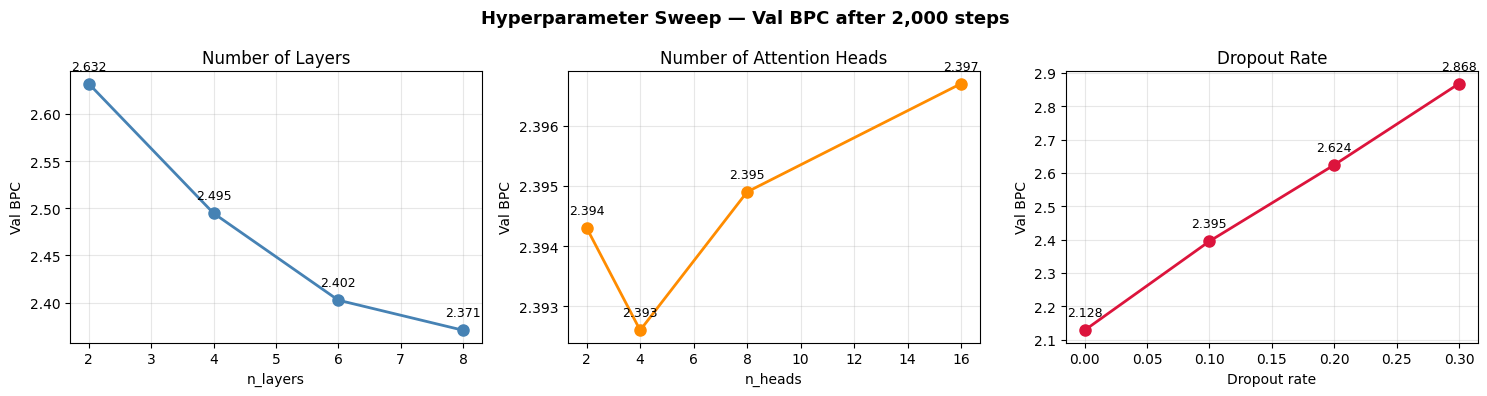

Sweep summary plot saved.


In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Layers ──────────────────────────────────────────────────────
ax = axes[0]
xs = [r["n_layers"] for r in sweep_results]
ys = [r["val_bpc"] for r in sweep_results]
ax.plot(xs, ys, "o-", color="steelblue", linewidth=2, markersize=8)
for x, y in zip(xs, ys):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_xlabel("n_layers"); ax.set_ylabel("Val BPC")
ax.set_title("Number of Layers"); ax.grid(True, alpha=0.3)

# ── Attention heads ─────────────────────────────────────────────
ax = axes[1]
xs = [r["n_heads"] for r in head_results]
ys = [r["val_bpc"] for r in head_results]
ax.plot(xs, ys, "o-", color="darkorange", linewidth=2, markersize=8)
for x, y in zip(xs, ys):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_xlabel("n_heads"); ax.set_ylabel("Val BPC")
ax.set_title("Number of Attention Heads"); ax.grid(True, alpha=0.3)

# ── Dropout ─────────────────────────────────────────────────────
ax = axes[2]
xs = [r["dropout"] for r in dropout_results]
ys = [r["val_bpc"] for r in dropout_results]
ax.plot(xs, ys, "o-", color="crimson", linewidth=2, markersize=8)
for x, y in zip(xs, ys):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_xlabel("Dropout rate"); ax.set_ylabel("Val BPC")
ax.set_title("Dropout Rate"); ax.grid(True, alpha=0.3)

plt.suptitle("Hyperparameter Sweep — Val BPC after 2,000 steps",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["out_dir"], "hyperparam_sweep.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Sweep summary plot saved.")
